# Table/Text Keyword and Indicator Extraction

This notebook extracts fence-related keywords and indicators from ADE chunks tagged as "table" or "text" (excluding logo, figure, architectural_drawing types).

Features:
1. Uses LLM for semantic extraction (not keyword matching)
2. Extracts both keywords AND indicators in a single LLM call
3. Uses PDF blocks (`get_text("blocks")`) for natural text grouping
4. Visualizes keywords and indicators with different colors
5. Returns structured JSON for downstream analysis
6. Bounding boxes from OCR + PDF text FULL LINES (not just matched tokens)


In [ ]:
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import json
import re

import fitz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import toml
from IPython.display import display
from matplotlib.patches import Rectangle

from hybrid_page_extractor import extract_page_sources, normalize_document_ai_config
from utils import retry_with_backoff
from langchain_core.messages import HumanMessage
from openai import RateLimitError, APIError, APITimeoutError

plt.rcParams["figure.dpi"] = 144
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", None)


✅ Comprehensive text extraction available


In [ ]:
SECRETS_PATH = Path(".streamlit/secrets.toml")
if not SECRETS_PATH.exists():
    raise FileNotFoundError("Expected .streamlit/secrets.toml with API keys.")

secrets = toml.load(SECRETS_PATH)

ADE_API_KEY = secrets.get("LANDINGAI_API_KEY")
if not ADE_API_KEY:
    raise ValueError("Missing LANDINGAI_API_KEY in secrets.toml")

PDF_PATH = Path("subset_gold/selected_pages_no_annotations.pdf")
PAGE_NUMBER = 2  # change here to inspect a different page

raw_doc_ai_config: Optional[Dict] = None
if "google_cloud" in secrets and "gcp_service_account" in secrets:
    raw_doc_ai_config = {
        "project_number": secrets["google_cloud"].get("project_number"),
        "location": secrets["google_cloud"].get("location"),
        "processor_id": secrets["google_cloud"].get("processor_id"),
        "service_account_info": dict(secrets["gcp_service_account"]),
    }
    doc_ai_config = normalize_document_ai_config(raw_doc_ai_config)
else:
    doc_ai_config = None
    print("⚠️ Google Cloud credentials missing; OCR results will be empty.")

pdf_doc = fitz.open(str(PDF_PATH))
page_index = PAGE_NUMBER - 1
if page_index < 0 or page_index >= len(pdf_doc):
    raise IndexError(f"Page {PAGE_NUMBER} out of bounds for document with {len(pdf_doc)} pages")

pdf_page = pdf_doc[page_index]
page_width = float(pdf_page.rect.width)
page_height = float(pdf_page.rect.height)

print(f"PDF: {PDF_PATH} → {len(pdf_doc)} pages")
print(f"Inspecting page {PAGE_NUMBER} (0-based index {page_index})")
print(f"Page size: {page_width:.1f} × {page_height:.1f} pts")
if doc_ai_config and doc_ai_config.get("client"):
    print("✅ Document AI client initialised")
else:
    print("⚠️ Document AI client not available")


PDF: subset_gold/selected_pages_no_annotations.pdf → 5 pages
Inspecting page 2 (0-based index 1)
Page size: 2592.0 × 1728.0 pts
✅ Document AI client initialised


E0000 00:00:1763350102.798041  755447 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [ ]:
page_sources = extract_page_sources(
    pdf=PDF_PATH,
    page_number=PAGE_NUMBER,
    ade_api_key=ADE_API_KEY,
    doc_ai_config=doc_ai_config,
)

pdf_blocks: List[Dict] = page_sources["pdf_blocks"]
pdf_words: List[Dict] = page_sources["pdf_words"]
ocr_tokens: List[Dict] = page_sources["ocr_tokens"]
ade_chunks: List[Dict] = page_sources["ade_chunks"]

print("Extraction summary:")
print(f"  PDF blocks: {len(pdf_blocks)}")
print(f"  PDF words: {len(pdf_words)}")
print(f"  OCR tokens: {len(ocr_tokens)}")
print(f"  ADE chunks: {len(ade_chunks)}")

# Filter chunks to only table and text types
table_text_chunks = [
    chunk for chunk in ade_chunks 
    if chunk.get("type", "").lower() in ["table", "text"]
]
print(f"  Table/Text chunks: {len(table_text_chunks)}")

with pd.option_context("display.max_colwidth", 120):
    display(pd.DataFrame(table_text_chunks)[["id", "type", "x0", "y0", "x1", "y1", "markdown", "text"]].head(10))


Extraction summary:
  PDF blocks: 334
  PDF words: 1620
  OCR tokens: 2011
  ADE chunks: 19
  Table/Text chunks: 14


,id,type,x0,y0,x1,y1,markdown,text
0,a9b2d4f2-05fb-4f97-b230-5324f615dbfc,table,588.969880,1279.166714,1493.378946,1701.858685,"<a id='a9b2d4f2-05fb-4f97-b230-5324f615dbfc'></a>\n\n<table id=""1-1"">\n<tr><td id=""1-2"" colspan=""3"">KEYNOTES</td></t...",
1,def91d02-89e7-4b99-ae04-af8c715b8e80,text,1488.795382,33.355419,1939.974936,255.497892,<a id='def91d02-89e7-4b99-ae04-af8c715b8e80'></a>\n\n# PROJECT TEAM\n\n## OWNER / DEVELOPER\nRYAN COMPANIES\n3900 E....,
2,d2e63d7a-e34a-4ca4-8331-49392b0f05be,text,1488.134605,255.449175,1940.470402,471.657280,<a id='d2e63d7a-e34a-4ca4-8331-49392b0f05be'></a>\n\n## CITY OF PHOENIX NOTES\n\n* DEVELOPMENT AND USE OF THIS SITE ...,
3,c769eeed-53f0-4709-9a7f-9e7ac24b48f6,text,1487.131931,471.103363,1941.108467,1156.963348,<a id='c769eeed-53f0-4709-9a7f-9e7ac24b48f6'></a>\n\n## LEGAL DESCRIPTION\n\nA PORTION OF THE WEST HALF OF SECTION 1...,
4,fbea7a4b-d39f-475d-8d94-a2ed390025aa,text,1488.809904,1156.452690,1940.896345,1317.141541,<a id='fbea7a4b-d39f-475d-8d94-a2ed390025aa'></a>\n\n# PROJECT DESCRIPTION\n\nSCOPE OF WORK:\nTHIS SUBMITTAL CONSIST...,
5,9aa56ef9-0ddc-4e24-b873-c72f539dc58c,text,1943.694872,34.719767,2391.016989,1026.824387,<a id='9aa56ef9-0ddc-4e24-b873-c72f539dc58c'></a>\n\n# PROJECT DATA\n\n## SITE DATA\nZONING: CP/CGP (GENERAL COMMERC...,
6,52fbd5b8-3c13-42e9-9a29-01c06668a903,text,2392.607672,394.055660,2586.323690,438.116930,"<a id='52fbd5b8-3c13-42e9-9a29-01c06668a903'></a>\n\n## OWNERSHIP OF INSTRUMENTS OF SERVICE\n\nAll reports, plans, s...",
7,8a74ec83-d81f-47f2-af66-e97095dbe416,text,2414.137665,720.513885,2567.961159,1262.280075,"<a id='8a74ec83-d81f-47f2-af66-e97095dbe416'></a>\n\n17 NORTH\nBUILDING C\n2350 W CORPORATE CENTER DRIVE PHOENIX, AZ...",
8,a439ffba-c4a6-4988-ac5d-dbb8522c63a2,text,2395.967171,1263.285736,2585.692886,1305.624023,<a id='a439ffba-c4a6-4988-ac5d-dbb8522c63a2'></a>\n\nCurrent Submittal: PERMIT SET\n08/26/24,
9,545855c7-76fe-41cc-b52e-7ed6ea5f9c72,text,2395.861187,1264.287277,2586.708538,1313.052773,<a id='545855c7-76fe-41cc-b52e-7ed6ea5f9c72'></a>\n\nCurrent Submittal: PERMIT SET\n08/26/24\n\nRevisions:,


In [ ]:
# Note: PDF blocks, words, and OCR tokens are already extracted in cell 3 via extract_page_sources()
# We use OCR + PDF text (blocks + words) combined for bounding boxes, not ADE chunks
print(f"✅ Using OCR tokens + PDF blocks + PDF words for bounding box matching")
print(f"   OCR tokens: {len(ocr_tokens)}")
print(f"   PDF blocks: {len(pdf_blocks)}")
print(f"   PDF words: {len(pdf_words)}")


✅ Using OCR tokens + PDF blocks + PDF words for bounding box matching
   OCR tokens: 2011
   PDF blocks: 334
   PDF words: 1620


In [ ]:
legend_llm = None
openai_api_key = secrets.get("OPENAI_API_KEY") or secrets.get("openai_api_key")
if openai_api_key:
    try:
        from langchain_openai import ChatOpenAI
        
        legend_llm = ChatOpenAI(
            model="gpt-4o-mini",
            temperature=0,
            api_key=openai_api_key,
            timeout=180,
            max_retries=2,
        )
        print("✅ Legend LLM initialised (gpt-4o-mini)")
    except Exception as exc:
        print(f"⚠️ Failed to initialise legend LLM: {exc}")
else:
    print("⚠️ OPENAI_API_KEY missing; extraction will be skipped.")


✅ Legend LLM initialised (gpt-4o-mini)


In [ ]:
FENCE_KEYWORDS = [
    "fence",
    "fencing",
    "gate",
    "barrier",
    "guardrail",
    "post",
    "mesh",
    "panel",
    "chain link",
    "masonry",
    "bollard",
    "wall",
    "railing",
    "enclosure",
    "perimeter",
    "screen",
    "security",
]

def extract_keywords_and_indicators_llm(
    chunk_text: str,
    fence_keywords: List[str],
    llm
) -> List[Dict]:
    """Extract fence-related keywords and their associated indicators from chunk text using LLM."""
    if not llm or not chunk_text:
        return []
    
    text_content = chunk_text[:5000] if len(chunk_text) > 5000 else chunk_text
    
    prompt = f"""You are analyzing text content from an architectural/engineering drawing that may contain fence-related elements and their indicator codes.

TASK: Extract fence-related keywords/terms AND their associated indicator codes (if present).

KEYWORD EXTRACTION:
- Identify terms related to: {', '.join(fence_keywords)}
- Use semantic understanding (not just exact string matching)
- Include synonyms and related construction terms

INDICATOR CODE EXTRACTION:
- Codes appear near or with their descriptions

EXCLUSION RULES (do NOT extract):
- Dimensions: Measurements with units (e.g., "10'", "6'-0\\"", "3.5 ft")
- Dates: Year or date formats (e.g., "2024", "9/9/24")
- Quantities: Standalone numbers without descriptive context (e.g., "43", "2 BOLTS")

OUTPUT FORMAT:
Return STRICT JSON only (no markdown, no explanations):
{{
  "results": [
    {{
      "keyword": "<fence-related term>",
      "indicator": "<indicator code>" or null,
      "description": "<full description text>"
    }}
  ]
}}

Text to analyze:
{text_content}
""".strip()
    
    try:
        raw_obj = retry_with_backoff(llm.invoke, [HumanMessage(content=prompt)])
        raw = raw_obj.content if hasattr(raw_obj, "content") else str(raw_obj)
        
        if not raw or not raw.strip():
            return []
        
        raw_clean = raw.strip()
        json_match = re.search(r'```json\s*([\s\S]*?)\s*```', raw_clean, re.IGNORECASE)
        if json_match:
            raw_clean = json_match.group(1).strip()
        elif raw_clean.startswith('```'):
            raw_clean = re.sub(r'^```[a-z]*\s*', '', raw_clean)
            raw_clean = re.sub(r'\s*```$', '', raw_clean).strip()
        
        if raw_clean.startswith('{'):
            parsed = json.loads(raw_clean)
        else:
            json_match = re.search(r'\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}', raw_clean)
            if json_match:
                parsed = json.loads(json_match.group(0))
            else:
                return []
        
        results = parsed.get("results", [])
        validated = []
        
        for item in results:
            keyword = (item.get("keyword", "") or "").strip()
            indicator = item.get("indicator")
            description = (item.get("description", "") or "").strip()
            
            if not keyword:
                continue
            
            validated_indicator = None
            if indicator:
                indicator_str = str(indicator).strip()
                code_clean = re.sub(r'[^\d]', '', indicator_str)
                if code_clean and code_clean.isdigit() and 3 <= len(code_clean) <= 5:
                    validated_indicator = code_clean
            
            validated.append({
                "keyword": keyword,
                "indicator": validated_indicator,
                "description": description or keyword
            })
        
        return validated
    except Exception as e:
        print(f"extract_keywords_and_indicators_llm error: {e}")
        return []


In [ ]:
def group_items_by_line(items: List[Dict], y_tolerance: float) -> List[List[Dict]]:
    """Group items (OCR tokens or PDF words) by line based on Y coordinates."""
    if not items:
        return []
    sorted_items = sorted(
        [item for item in items if item.get("text")],
        key=lambda it: (it.get("y0", 0.0), it.get("x0", 0.0))
    )
    lines: List[List[Dict]] = []
    current: List[Dict] = []
    last_y: Optional[float] = None
    for item in sorted_items:
        y0 = float(item.get("y0", 0.0))
        if last_y is None or abs(y0 - last_y) <= y_tolerance:
            current.append(item)
        else:
            if current:
                lines.append(sorted(current, key=lambda it: it.get("x0", 0.0)))
            current = [item]
        last_y = y0
    if current:
        lines.append(sorted(current, key=lambda it: it.get("x0", 0.0)))
    return lines


def combine_bbox(items: List[Dict]) -> Tuple[float, float, float, float]:
    """Combine bounding boxes from multiple items."""
    x0 = min(float(item.get("x0", 0.0)) for item in items)
    y0 = min(float(item.get("y0", 0.0)) for item in items)
    x1 = max(float(item.get("x1", 0.0)) for item in items)
    y1 = max(float(item.get("y1", 0.0)) for item in items)
    return x0, y0, x1, y1


def make_highlight(items: List[Dict], fallback_text: str) -> Optional[Dict]:
    """Create highlight dict from items, matching the working code approach."""
    if not items:
        return None
    x0, y0, x1, y1 = combine_bbox(items)
    text_join = " ".join(item.get("text", "") for item in items).strip()
    return {
        "x0": x0,
        "y0": y0,
        "x1": x1,
        "y1": y1,
        "text": text_join or fallback_text
    }


def find_text_span_in_lines(
    search_text: str,
    lines: List[List[Dict]],
    chunk_bbox: Optional[Tuple[float, float, float, float]] = None,
    tolerance: float = 50.0
) -> Optional[Dict]:
    """
    Find matching text in lines - returns FULL LINE bbox (not just the matched token).
    This ensures we visualize the entire text region (e.g., "0113 MANUAL ROLLING GATES" not just "0113").
    """
    if not search_text or not lines:
        return None
    
    # Normalize search text - remove non-alphanumeric for matching
    target = re.sub(r'[^0-9A-Za-z]', '', search_text).lower()
    original_text = search_text
    
    # Filter by chunk bbox if provided
    chunk_x0 = chunk_y0 = chunk_x1 = chunk_y1 = None
    if chunk_bbox:
        chunk_x0, chunk_y0, chunk_x1, chunk_y1 = chunk_bbox
    
    def is_in_region(x0, y0, x1, y1):
        if not chunk_bbox:
            return True
        return not (x1 < chunk_x0 - tolerance or x0 > chunk_x1 + tolerance or
                   y1 < chunk_y0 - tolerance or y0 > chunk_y1 + tolerance)
    
    for line in lines:
        if not line:
            continue
        
        # Filter line items by region
        line_items = [item for item in line if is_in_region(
            float(item.get("x0", 0)), float(item.get("y0", 0)),
            float(item.get("x1", 0)), float(item.get("y1", 0))
        )]
        if not line_items:
            continue
        
        # Check if any token in the line matches
        matched = False
        
        # Direct token checks (matches working code)
        for item in line_items:
            raw_text = item.get("text", "") or ""
            clean_text = re.sub(r'[^0-9A-Za-z]', '', raw_text).lower()
            if not clean_text:
                continue
            if clean_text == target or clean_text.startswith(target):
                matched = True
                break
            if target in clean_text:
                matched = True
                break
        
        # Combine sequential tokens to match fragmented text (matches working code)
        if not matched:
            tokens = []
            for item in line_items:
                clean_text = re.sub(r'[^0-9A-Za-z]', '', item.get("text", "") or "").lower()
                if clean_text:
                    tokens.append((item, clean_text))
            n = len(tokens)
            for i in range(n):
                combined = ""
                for j in range(i, n):
                    combined += tokens[j][1]
                    if combined == target:
                        matched = True
                        break
                    if not target.startswith(combined):
                        break
                if matched:
                    break
        
        # If matched, return FULL LINE bbox (not just the matched token)
        if matched:
            # Return bbox for entire line_items, not just the matched token
            return make_highlight(line_items, original_text)
    
    return None


def find_text_in_ocr_and_pdf(
    search_text: str,
    ocr_tokens: List[Dict],
    pdf_blocks: List[Dict],
    pdf_words: List[Dict],
    chunk_bbox: Optional[Tuple[float, float, float, float]] = None,
    tolerance: float = 50.0
) -> Optional[Dict]:
    """Find matching text in OCR tokens and PDF text combined. Returns FULL LINE bbox from OCR/PDF."""
    # Priority 1: Search OCR tokens grouped by lines (most accurate)
    if ocr_tokens:
        ocr_lines = group_items_by_line(ocr_tokens, y_tolerance=10.0)
        result = find_text_span_in_lines(search_text, ocr_lines, chunk_bbox, tolerance)
        if result:
            result["source"] = "ocr"
            return result
    
    # Priority 2: Search PDF blocks
    if pdf_blocks:
        chunk_x0 = chunk_y0 = chunk_x1 = chunk_y1 = None
        if chunk_bbox:
            chunk_x0, chunk_y0, chunk_x1, chunk_y1 = chunk_bbox
        
        def is_in_region(x0, y0, x1, y1):
            if not chunk_bbox:
                return True
            return not (x1 < chunk_x0 - tolerance or x0 > chunk_x1 + tolerance or
                       y1 < chunk_y0 - tolerance or y0 > chunk_y1 + tolerance)
        
        search_lower = search_text.lower()
        search_clean = re.sub(r'[^0-9A-Za-z]', '', search_lower)
        
        for block in pdf_blocks:
            block_x0 = float(block.get("x0", 0))
            block_y0 = float(block.get("y0", 0))
            block_x1 = float(block.get("x1", 0))
            block_y1 = float(block.get("y1", 0))
            block_text = block.get("text", "") or ""
            
            if not is_in_region(block_x0, block_y0, block_x1, block_y1):
                continue
            
            block_clean = re.sub(r'[^0-9A-Za-z]', '', block_text.lower())
            # Simple matching: check if search text appears in block
            if search_clean in block_clean or block_clean in search_clean or search_lower in block_text.lower():
                return {
                    "x0": block_x0, "y0": block_y0, "x1": block_x1, "y1": block_y1,
                    "text": block_text, "source": "pdf_block"
                }
    
    # Priority 3: Search PDF words grouped by lines
    if pdf_words:
        pdf_lines = group_items_by_line(pdf_words, y_tolerance=5.0)
        result = find_text_span_in_lines(search_text, pdf_lines, chunk_bbox, tolerance)
        if result:
            result["source"] = "pdf_words"
            return result
    
    return None


def extract_keywords_and_indicators_from_chunks(
    ade_chunks: List[Dict],
    ocr_tokens: List[Dict],
    pdf_blocks: List[Dict],
    pdf_words: List[Dict],
    fence_keywords: List[str],
    llm,
    page_width: float,
    page_height: float
) -> List[Dict]:
    """
    Main extraction function. 
    Bounding boxes from OCR + PDF text FULL LINES (not ADE chunks, not just tokens).
    """
    if not llm:
        print("⚠️ LLM not available; skipping extraction.")
        return []
    
    # Filter chunks to only table and text types
    table_text_chunks = [c for c in ade_chunks if c.get("type", "").lower() in ["table", "text"]]
    
    if not table_text_chunks:
        print("⚠️ No table/text chunks found.")
        return []
    
    print(f"Processing {len(table_text_chunks)} table/text chunks...")
    all_results = []
    
    for chunk in table_text_chunks:
        chunk_type = chunk.get("type", "").lower()
        chunk_id = chunk.get("id", "")
        chunk_text = chunk.get("markdown", chunk.get("text", ""))
        
        if not chunk_text:
            continue
        
        chunk_bbox = (
            float(chunk.get("x0", 0)), float(chunk.get("y0", 0)),
            float(chunk.get("x1", 0)), float(chunk.get("y1", 0))
        )
        
        # Extract keywords and indicators using LLM
        llm_results = extract_keywords_and_indicators_llm(
            chunk_text=chunk_text, fence_keywords=fence_keywords, llm=llm
        )
        
        # For each LLM result, find coordinates in OCR + PDF text
        for llm_result in llm_results:
            keyword = llm_result.get("keyword", "")
            indicator = llm_result.get("indicator")
            description = llm_result.get("description", "")
            
            # Strategy: When we have both keyword and indicator, search for the keyword first
            # to get the full line (which should contain the indicator). This ensures we get
            # the full line like "0113 4' WIDE PAINTED NO PARKING ZONE STRIPING" not just "0113".
            final_bbox = None
            
            if indicator and keyword:
                # Priority 1: Search for keyword (which should be in the full description line)
                keyword_bbox = find_text_in_ocr_and_pdf(
                    search_text=keyword, ocr_tokens=ocr_tokens,
                    pdf_blocks=pdf_blocks, pdf_words=pdf_words, chunk_bbox=chunk_bbox
                )
                if keyword_bbox:
                    final_bbox = keyword_bbox
                else:
                    # Fallback: try description
                    desc_bbox = find_text_in_ocr_and_pdf(
                        search_text=description, ocr_tokens=ocr_tokens,
                        pdf_blocks=pdf_blocks, pdf_words=pdf_words, chunk_bbox=chunk_bbox
                    )
                    if desc_bbox:
                        final_bbox = desc_bbox
            elif keyword:
                # Only keyword, no indicator - search for keyword
                keyword_bbox = find_text_in_ocr_and_pdf(
                    search_text=keyword, ocr_tokens=ocr_tokens,
                    pdf_blocks=pdf_blocks, pdf_words=pdf_words, chunk_bbox=chunk_bbox
                )
                if keyword_bbox:
                    final_bbox = keyword_bbox
            elif indicator:
                # Only indicator, no keyword - search for indicator
                indicator_bbox = find_text_in_ocr_and_pdf(
                    search_text=indicator, ocr_tokens=ocr_tokens,
                    pdf_blocks=pdf_blocks, pdf_words=pdf_words, chunk_bbox=chunk_bbox
                )
                if indicator_bbox:
                    final_bbox = indicator_bbox
            
            if not final_bbox:
                continue  # Skip if not found in OCR + PDF
            
            result = {
                "keyword": keyword,
                "indicator": indicator,
                "description": description,
                "x0": final_bbox["x0"], "y0": final_bbox["y0"],
                "x1": final_bbox["x1"], "y1": final_bbox["y1"],
                "chunk_type": chunk_type, "chunk_id": chunk_id,
                "bbox_source": final_bbox.get("source", "unknown")
            }
            all_results.append(result)
    
    print(f"✅ Extracted {len(all_results)} keyword/indicator pairs")
    print(f"   (Bounding boxes from OCR + PDF text FULL LINES, not just tokens)")
    return all_results


In [ ]:
# Run extraction
extraction_results = extract_keywords_and_indicators_from_chunks(
    ade_chunks=ade_chunks,
    ocr_tokens=ocr_tokens,
    pdf_blocks=pdf_blocks,
    pdf_words=pdf_words,
    fence_keywords=FENCE_KEYWORDS,
    llm=legend_llm,
    page_width=page_width,
    page_height=page_height
)

print(f"\nExtraction Results:")
print(f"  Total results: {len(extraction_results)}")
print(f"  Results with indicators: {sum(1 for r in extraction_results if r.get('indicator'))}")
print(f"  Results without indicators: {sum(1 for r in extraction_results if not r.get('indicator'))}")

if extraction_results:
    display(pd.DataFrame(extraction_results))


Processing 14 table/text chunks...
✅ Extracted 5 keyword/indicator pairs
   (Bounding boxes from OCR + PDF text FULL LINES, not just tokens)

Extraction Results:
  Total results: 5
  Results with indicators: 5
  Results without indicators: 0


,keyword,indicator,description,x0,y0,x1,y1,chunk_type,chunk_id,bbox_source
0,MANUAL ROLLING GATES,0113,MANUAL ROLLING GATES,597.158359,1416.969257,767.709014,1425.288002,table,a9b2d4f2-05fb-4f97-b230-5324f615dbfc,combined
1,BOLLARD,0508,"CONCRETE FILLED 6"" DIA STEEL PIPE BOLLARD - PA...",598.082743,1511.248947,1527.098459,1627.712196,table,a9b2d4f2-05fb-4f97-b230-5324f615dbfc,combined
2,SCREEN WALL,0401,CMU PARKING SCREEN WALL COURSING AND FINISH PE...,599.879761,1324.201294,1027.431152,1669.754639,table,a9b2d4f2-05fb-4f97-b230-5324f615dbfc,pdf_block
3,SCREEN WALL,0402,"CMU TRUCK COURT SCREEN WALL, COURSING AND FINI...",599.879761,1324.201294,1027.431152,1669.754639,table,a9b2d4f2-05fb-4f97-b230-5324f615dbfc,pdf_block
4,SCREEN WALL,0403,STEPPED CMU SCREEN WALL AT RAMP,599.879761,1324.201294,1027.431152,1669.754639,table,a9b2d4f2-05fb-4f97-b230-5324f615dbfc,pdf_block


In [ ]:
# Prepare page image for visualization
RENDER_DPI = 144
page_pix = pdf_page.get_pixmap(dpi=RENDER_DPI)
page_img = np.frombuffer(page_pix.samples, dtype=np.uint8).reshape(page_pix.height, page_pix.width, page_pix.n)
if page_pix.n == 4:
    page_img = page_img[:, :, :3]

# IMPORTANT: Scale factors to convert PDF points to rendered image pixels
scale_x = page_pix.width / page_width
scale_y = page_pix.height / page_height

print(f"Rendered preview at {RENDER_DPI} DPI → image {page_pix.width}×{page_pix.height}")
print(f"PDF page size: {page_width:.1f} × {page_height:.1f} pts")
print(f"Scale factors: {scale_x:.4f} × {scale_y:.4f} (pts → pixels)")


def show_page(figsize=(10, 14), title: Optional[str] = None):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(page_img)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold')
    return fig, ax


def add_boxes(
    ax,
    records: List[Dict],
    color: str,
    label_key: Optional[str] = None,
    linewidth: float = 1.4,
    alpha: float = 0.5,
):
    """Add bounding boxes to axis. Coordinates are in PDF points, converted to pixels using scale factors."""
    for rec in records:
        # Convert PDF points to rendered image pixels using scale factors
        x0 = float(rec.get("x0", 0.0)) * scale_x
        y0 = float(rec.get("y0", 0.0)) * scale_y
        x1 = float(rec.get("x1", 0.0)) * scale_x
        y1 = float(rec.get("y1", 0.0)) * scale_y
        width = max(x1 - x0, 1.0)
        height = max(y1 - y0, 1.0)

        rect = Rectangle((x0, y0), width, height, linewidth=linewidth, edgecolor=color, facecolor=(0, 0, 0, 0))
        rect.set_alpha(alpha)
        ax.add_patch(rect)

        if label_key:
            text = rec.get(label_key)
            if text:
                ax.text(
                    x0,
                    max(y0 - 6, 8),
                    str(text)[:42],
                    color="black",
                    fontsize=8,
                    bbox=dict(facecolor=color, alpha=alpha, edgecolor="none", pad=1.5),
                )


Rendered preview at 144 DPI → image 5184×3456
PDF page size: 2592.0 × 1728.0 pts
Scale factors: 2.0000 × 2.0000 (pts → pixels)


Visualization breakdown:
  Keywords only (cyan): 0
  Indicators (with keywords, orange): 5
  Total highlights: 5


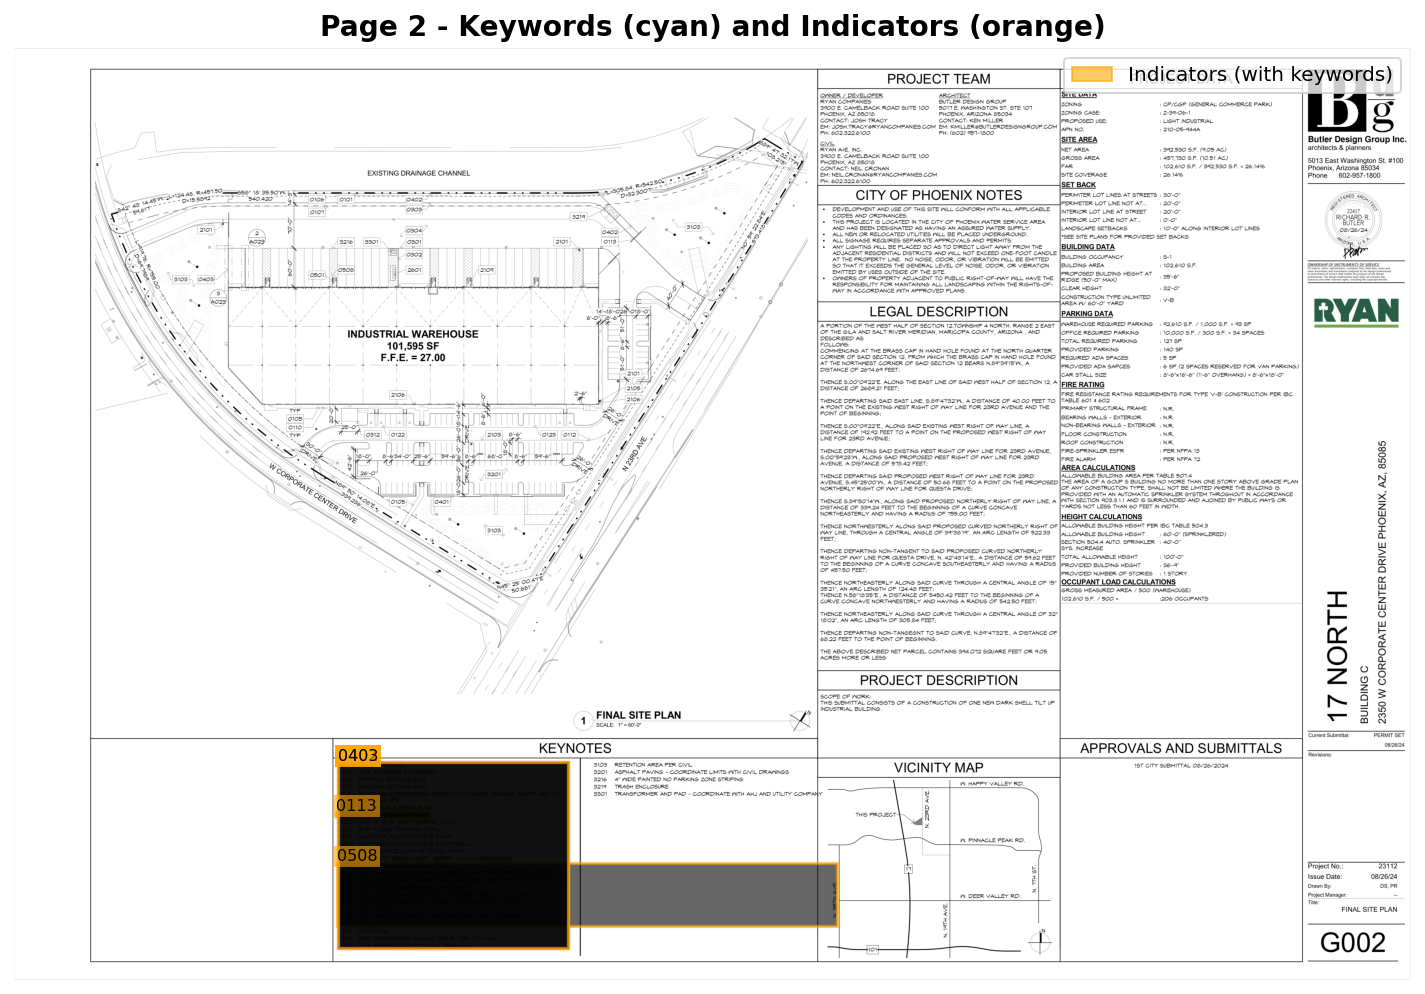

In [ ]:
# Separate keywords and indicators for visualization
keyword_only_results = [r for r in extraction_results if not r.get("indicator")]
indicator_results = [r for r in extraction_results if r.get("indicator")]

print(f"Visualization breakdown:")
print(f"  Keywords only (cyan): {len(keyword_only_results)}")
print(f"  Indicators (with keywords, orange): {len(indicator_results)}")
print(f"  Total highlights: {len(extraction_results)}")

fig, ax = show_page(title=f"Page {PAGE_NUMBER} - Keywords (cyan) and Indicators (orange)")

# Draw keywords only in cyan
if keyword_only_results:
    add_boxes(ax, keyword_only_results, color="cyan", label_key="keyword", linewidth=1.4, alpha=0.5)

# Draw indicators (which include keywords) in orange
if indicator_results:
    add_boxes(ax, indicator_results, color="orange", label_key="indicator", linewidth=1.6, alpha=0.6)

# Add legend
from matplotlib.patches import Patch
legend_elements = []
if keyword_only_results:
    legend_elements.append(Patch(facecolor='cyan', edgecolor='cyan', alpha=0.5, label='Keywords only'))
if indicator_results:
    legend_elements.append(Patch(facecolor='orange', edgecolor='orange', alpha=0.6, label='Indicators (with keywords)'))
if legend_elements:
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
# Summary statistics
summary = {
    "chunks_processed": len([c for c in ade_chunks if c.get("type", "").lower() in ["table", "text"]]),
    "total_extractions": len(extraction_results),
    "keywords_only": len(keyword_only_results),
    "with_indicators": len(indicator_results),
    "unique_keywords": len(set(r["keyword"] for r in extraction_results)),
    "unique_indicators": len(set(r["indicator"] for r in extraction_results if r.get("indicator"))),
}

print("=" * 60)
print("EXTRACTION SUMMARY")
print("=" * 60)
for key, value in summary.items():
    print(f"  {key.replace('_', ' ').title()}: {value}")

print("\nSample results:")
if extraction_results:
    sample_df = pd.DataFrame(extraction_results[:10])
    display(sample_df[["keyword", "indicator", "description", "chunk_type"]])
else:
    print("  No results extracted.")

# Export results as JSON for downstream analysis
results_json = json.dumps(extraction_results, indent=2)
print(f"\n✅ Results are JSON-serializable ({len(results_json)} characters)")


EXTRACTION SUMMARY
  Chunks Processed: 14
  Total Extractions: 5
  Keywords Only: 0
  With Indicators: 2
  Unique Keywords: 3
  Unique Indicators: 5

Sample results:


,keyword,indicator,description,chunk_type
0,MANUAL ROLLING GATES,0113,MANUAL ROLLING GATES,table
1,BOLLARD,0508,"CONCRETE FILLED 6"" DIA STEEL PIPE BOLLARD - PA...",table
2,SCREEN WALL,0401,CMU PARKING SCREEN WALL COURSING AND FINISH PE...,table
3,SCREEN WALL,0402,"CMU TRUCK COURT SCREEN WALL, COURSING AND FINI...",table
4,SCREEN WALL,0403,STEPPED CMU SCREEN WALL AT RAMP,table



✅ Results are JSON-serializable (1817 characters)


In [ ]:
pdf_doc.close()


In [ ]:
SECRETS_PATH = Path(".streamlit/secrets.toml")
if not SECRETS_PATH.exists():
    raise FileNotFoundError("Expected .streamlit/secrets.toml with API keys.")

secrets = toml.load(SECRETS_PATH)

ADE_API_KEY = secrets.get("LANDINGAI_API_KEY")
if not ADE_API_KEY:
    raise ValueError("Missing LANDINGAI_API_KEY in secrets.toml")

PDF_PATH = Path("subset_gold/selected_pages_no_annotations.pdf")
PAGE_NUMBER = 2  # change here to inspect a different page

raw_doc_ai_config: Optional[Dict] = None
if "google_cloud" in secrets and "gcp_service_account" in secrets:
    raw_doc_ai_config = {
        "project_number": secrets["google_cloud"].get("project_number"),
        "location": secrets["google_cloud"].get("location"),
        "processor_id": secrets["google_cloud"].get("processor_id"),
        "service_account_info": dict(secrets["gcp_service_account"]),
    }
    doc_ai_config = normalize_document_ai_config(raw_doc_ai_config)
else:
    doc_ai_config = None
    print("⚠️ Google Cloud credentials missing; OCR results will be empty.")

pdf_doc = fitz.open(str(PDF_PATH))
page_index = PAGE_NUMBER - 1
if page_index < 0 or page_index >= len(pdf_doc):
    raise IndexError(f"Page {PAGE_NUMBER} out of bounds for document with {len(pdf_doc)} pages")

pdf_page = pdf_doc[page_index]
page_width = float(pdf_page.rect.width)
page_height = float(pdf_page.rect.height)

print(f"PDF: {PDF_PATH} → {len(pdf_doc)} pages")
print(f"Inspecting page {PAGE_NUMBER} (0-based index {page_index})")
print(f"Page size: {page_width:.1f} × {page_height:.1f} pts")
if doc_ai_config and doc_ai_config.get("client"):
    print("✅ Document AI client initialised")
else:
    print("⚠️ Document AI client not available")


PDF: subset_gold/selected_pages_no_annotations.pdf → 5 pages
Inspecting page 2 (0-based index 1)
Page size: 2592.0 × 1728.0 pts
✅ Document AI client initialised


E0000 00:00:1763350202.871323  755447 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.
